# Pha R — Ablation: mang T_phi nho hon (kiem dinh gia thuyet cho Nhip 2)

**Cau hoi:** ket qua Pha R (xem `docs/PHASE_R_REPORT.md`) cho thay Amortized (mang `[128,128,64]`) thua KSG ro ret o N=10,20 nhung thang ro tu N=30 tro len. Gia thuyet: mang lon co the dang **overfit vao corpus train**, tong quat kem o vung du lieu cuc ngan. Neu dung, mot mang **it tham so hon** (du van la MLP co dien) co the tong quat tot hon dung o vung N=10-20 dang can.

**Vi sao quan trong cho Nhip 2:** mach luong tu data re-uploading (6-8 qubit x 3-5 lop) co so tham so RAT it - tuong tu huong thu nghiem nay. Neu mang nho thang ro o day, do la ly do chinh dang de ky vong mach luong tu giup duoc. Neu mang nho KHONG cai thien, van de nam o noi khac (thiet ke loss, cach lay mau...) va mach luong tu (cung it tham so) nhieu kha nang cung khong giai quyet duoc.

**Thay doi DUY NHAT so voi ban chinh:** `hidden_dims: [16,16]` thay vi `[128,128,64]` (xem `configs/mine/amortized_small.yaml`) - moi thu khac giu nguyen de la 1 ablation sach.

**Khong can sinh lai corpus** - dung lai dung file `data/interim/synthetic_corpus/` da co tu notebook 01.

**Thoi gian:** da do thu 2 epoch tren dung corpus thuc te truoc khi giao notebook nay: ~77s/epoch (so voi ~186s/epoch cua mang lon o notebook 02) -> uoc tinh **~128 phut (~2.1 gio)** cho du 100 epoch. Van nen chay lai o 'uoc tinh thoi gian' o duoi de xac nhan tren may ban.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import yaml, time, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig, AmortizedTEEstimator
from pqrst.evaluation.grid import evaluate_estimators_on_grid, summarize_grid

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'mine'/'amortized_small.yaml', encoding='utf-8'))
cfg

{'train': {'hidden_dims': [16, 16],
  'learning_rate': 0.001,
  'windows_per_batch': 32,
  'max_epochs': 100,
  'patience': 15,
  'eval_n_shuffles': 20,
  'final_estimate_last_k_epochs': 10,
  'seed': 42},
 'eval': {'n_shuffles': 50}}

## 1. Nap corpus (tai su dung tu notebook 01, khong sinh lai)

In [2]:
corpus_dir = BASE / 'data' / 'interim' / 'synthetic_corpus'
train_windows = load_corpus(str(corpus_dir / 'train.npz'))
val_windows = load_corpus(str(corpus_dir / 'val.npz'))
test_windows = load_corpus(str(corpus_dir / 'test.npz'))
print(f'train={len(train_windows)}, val={len(val_windows)}, test={len(test_windows)}')

train=22950, val=4050, test=18000


## 2. Uoc tinh thoi gian truoc khi chay full

**Luon chay o nay truoc.** In ra thoi gian/epoch va uoc tinh cho toan bo `max_epochs` — kiem tra co hop ly (vai chuc phut, khong phai vai gio) truoc khi chay o tiep theo.

In [3]:
probe_cfg = AmortizedTrainConfig(**cfg['train'])
probe_cfg.max_epochs = 2
t0 = time.time()
_, _ = train_amortized(train_windows, val_windows, probe_cfg)
t_epoch = (time.time() - t0) / 2
full_epochs = cfg['train']['max_epochs']
print(f'Thoi gian/epoch: {t_epoch:.2f}s')
print(f'Uoc tinh cho {full_epochs} epoch: {t_epoch*full_epochs/60:.1f} phut')

Thoi gian/epoch: 75.06s
Uoc tinh cho 100 epoch: 125.1 phut


## 3. Huan luyen day du

In [4]:
train_cfg = AmortizedTrainConfig(**cfg['train'])
t0 = time.time()
est_small, hist_small = train_amortized(train_windows, val_windows, train_cfg)
print(f'Xong sau {(time.time()-t0)/60:.1f} phut, {len(hist_small["val_loss_history"])} epoch, '
      f'trung binh {hist_small["n_epochs_averaged"]} epoch cuoi de deploy')

Xong sau 115.7 phut, 100 epoch, trung binh 10 epoch cuoi de deploy


## 4. Loss curve

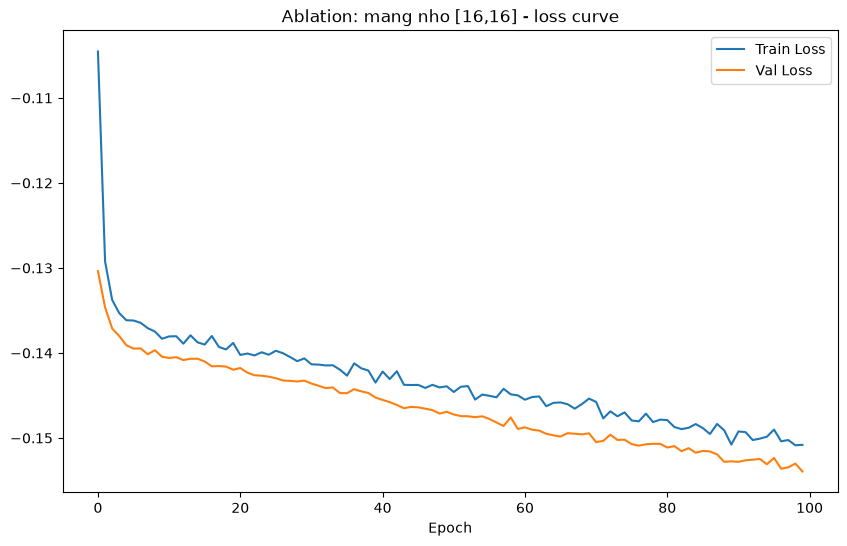

Val loss std (last 10 epoch): 0.0005061679093971544


In [5]:
plt.figure(figsize=(10,6))
plt.plot(hist_small['train_loss_history'], label='Train Loss')
plt.plot(hist_small['val_loss_history'], label='Val Loss')
plt.legend(); plt.xlabel('Epoch'); plt.title('Ablation: mang nho [16,16] - loss curve')
out_dir = BASE / 'results' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'phase_r_ablation_small_loss.png', dpi=100)
plt.show()
print('Val loss std (last 10 epoch):', np.std(hist_small['val_loss_history'][-10:]))

## 5. Luu checkpoint

In [6]:
ckpt_dir = BASE / 'results' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
est_small.save(str(ckpt_dir / 'phi_amortized_small.pt'))
print('Saved.')

Saved.


## 6. Danh gia tren tap TEST (chi estimator moi - khong chay lai KSG/Binning/Symbolic)

3 baseline + Amortized (mang lon) da co ket qua san trong `results/tables/phase_r_grid_summary.csv` tu truoc - chi can chay them `Amortized_Small` roi ghep lai, khong ton thoi gian chay lai KSG tren 18.000 cua so.

In [7]:
raw_small = evaluate_estimators_on_grid({'Amortized_Small': est_small}, test_windows, progress=True)
out_dir = BASE / 'results' / 'tables'
raw_small.to_csv(out_dir / 'phase_r_ablation_small_raw.csv', index=False)
summary_small = summarize_grid(raw_small)
summary_small.to_csv(out_dir / 'phase_r_ablation_small_summary.csv', index=False)
summary_small.head()

Evaluating windows: 100%|██████████| 18000/18000 [02:16<00:00, 132.02it/s]


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,c_0.0_noise_0.3,0.0,0.3,10,Amortized_Small,200,0,-0.021714,0.003558,0.004012,-0.029981,-0.013446
1,c_0.0_noise_0.3,0.0,0.3,20,Amortized_Small,200,0,-0.023669,0.002382,0.002931,-0.030433,-0.016905
2,c_0.0_noise_0.3,0.0,0.3,30,Amortized_Small,200,0,-0.021111,0.001878,0.002314,-0.027117,-0.015105
3,c_0.0_noise_0.3,0.0,0.3,50,Amortized_Small,200,0,-0.019728,0.001011,0.001395,-0.024135,-0.015321
4,c_0.0_noise_0.3,0.0,0.3,100,Amortized_Small,200,0,-0.022545,0.000588,0.001094,-0.025906,-0.019183


## 7. So sanh voi ket qua chinh (mang lon) — dung dung cau hoi dat ra o dau notebook

In [8]:
summary_main = pd.read_csv(BASE / 'results' / 'tables' / 'phase_r_grid_summary.csv')
combined = pd.concat([summary_main, summary_small], ignore_index=True)

agg = combined.groupby(['estimator', 'n_samples'])[['bias', 'variance', 'mse']].mean().round(5)
print(agg.loc[agg.index.get_level_values('n_samples') < 30].to_string())

                              bias  variance      mse
estimator       n_samples                            
Amortized       10        -0.06513   0.01168  0.01805
                20        -0.05631   0.00639  0.01122
Amortized_Small 10        -0.06354   0.01237  0.01836
                20        -0.05638   0.00679  0.01149
Binning         10         0.33052   0.02334  0.14330
                20         0.59407   0.01642  0.38100
KSG             10        -0.07814   0.00372  0.01700
                20        -0.05554   0.00535  0.01203
Symbolic        10         0.21558   0.02198  0.07939
                20         0.38639   0.01666  0.17592


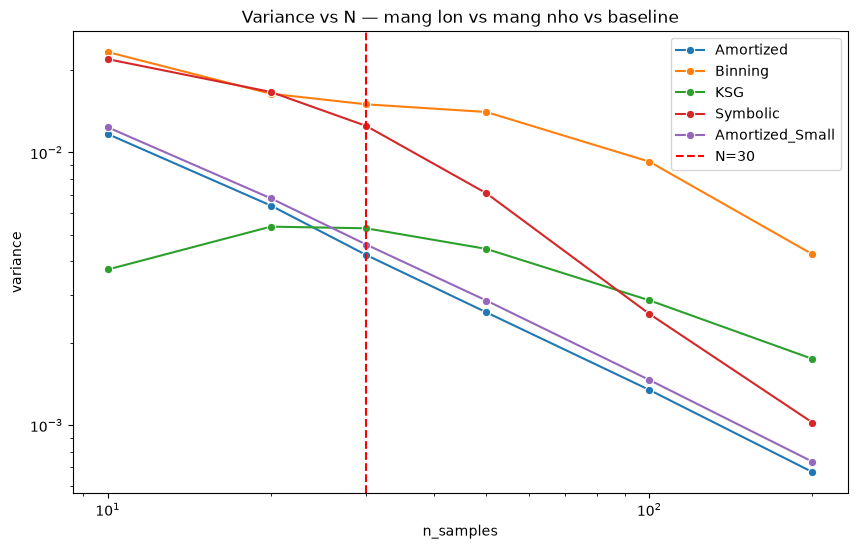

In [9]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.lineplot(data=combined, x='n_samples', y='variance', hue='estimator', marker='o', errorbar=None)
plt.axvline(30, color='r', linestyle='--', label='N=30')
plt.xscale('log'); plt.yscale('log')
plt.title('Variance vs N — mang lon vs mang nho vs baseline')
plt.legend()
plt.savefig(BASE / 'results' / 'figures' / 'phase_r_ablation_variance_comparison.png', dpi=100)
plt.show()

## 8. Verdict — mang nho co giup o N<30 khong?

In [10]:
pivot = combined[combined['n_samples'] < 30].pivot_table(
    index=['config_name', 'coupling_c', 'noise_std', 'n_samples'],
    columns='estimator', values='variance').reset_index()

n_cells = len(pivot)
beats_ksg_large = (pivot['Amortized'] < pivot['KSG']).sum()
beats_ksg_small = (pivot['Amortized_Small'] < pivot['KSG']).sum()

print(f'So o luoi N<30 kiem tra: {n_cells}')
print(f'Mang LON  (128,128,64) thang KSG: {beats_ksg_large}/{n_cells}')
print(f'Mang NHO  (16,16)      thang KSG: {beats_ksg_small}/{n_cells}')

if beats_ksg_small > beats_ksg_large:
    print('\n=> Mang nho THANG NHIEU HON mang lon o N<30 - xac nhan gia thuyet '
          "it tham so = tong quat tot hon o N nho\" - co co so de ky vong mach "
          'luong tu (cung it tham so) giup duoc o Nhip 2.')
elif beats_ksg_small == beats_ksg_large:
    print('\n=> Khong khac biet ro ret. Can xem xet huong khac (muc 6.2/6.3 '
          'trong PHASE_R_REPORT.md) truoc khi dau tu Nhip 2.')
else:
    print('\n=> Mang nho TE HON mang lon o N<30 - bac bo gia thuyet '
          "'it tham so giup o N nho'\" cho kien truc nay. Van de nhieu kha nang "
          'nam o thiet ke loss/cach lay mau, KHONG nam o so tham so - can xem lai '
          'truoc khi dau tu dung mach luong tu o Nhip 2.')

So o luoi N<30 kiem tra: 30
Mang LON  (128,128,64) thang KSG: 9/30
Mang NHO  (16,16)      thang KSG: 9/30

=> Khong khac biet ro ret. Can xem xet huong khac (muc 6.2/6.3 trong PHASE_R_REPORT.md) truoc khi dau tu Nhip 2.


## 9. Ket luan

*(dien sau khi chay xong: ket qua noi tren, quyet dinh huong tiep theo cho Nhip 2)*